# Build Individual Machine Learning Models
## Breast Cancer Wisconsin (Diagnostic) — Stage 3

Train **five** classification algorithms **separately** to build baseline
models and learn how each performs:

1. **Naive Bayes** (GaussianNB)
2. **Decision Tree**
3. **Random Forest**
4. **SVM** (Support Vector Classifier)
5. **XGBoost**

Each model is evaluated with **Accuracy, Precision, Recall, F1-score** and a
**Confusion Matrix**.

> **Positive class = malignant (0).** In this medical problem the costly error
> is a *false negative* (missing a malignant tumour), so we measure precision /
> recall with malignant as the positive class and watch **recall** closely.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
POS_LABEL = 0          # malignant = positive class
print("Ready. positive class = malignant (0)")

Ready. positive class = malignant (0)


## 2. Load Data & Reproduce the Leakage-Safe Split + Scaling

To keep this notebook **self-contained and reproducible**, we rebuild the exact
same stratified 80/20 split and training-only standardisation used in Stage 2
(`random_state=42`). This yields identical arrays to `processed/*.csv`.

In [2]:
df = pd.read_csv("breast_cancer_wisconsin.csv")
feature_cols = [c for c in df.columns if c not in ("target", "diagnosis")]
X = df[feature_cols]
y = df["target"]           # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)      # fit on TRAIN only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape} | Test: {X_test_s.shape}")
print("Train class balance:", dict(y_train.value_counts()))

Train: (455, 30) | Test: (114, 30)
Train class balance: {1: 285, 0: 170}


## 3. Define the Five Models

- **SVM** and **Naive Bayes** are sensitive to feature scale → use the
  **scaled** data.
- **Tree-based** models (Decision Tree, Random Forest, XGBoost) are
  scale-invariant, but using scaled data does no harm and keeps the interface
  uniform.
- `class_weight="balanced"` is applied where supported to respect the moderate
  class imbalance.

In [3]:
models = {
    "Naive Bayes":   GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE,
                                            class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300,
                                            random_state=RANDOM_STATE,
                                            class_weight="balanced", n_jobs=-1),
    "SVM":           SVC(kernel="rbf", probability=True,
                         random_state=RANDOM_STATE, class_weight="balanced"),
    "XGBoost":       XGBClassifier(n_estimators=300, max_depth=4,
                                   learning_rate=0.1, subsample=0.9,
                                   colsample_bytree=0.9, eval_metric="logloss",
                                   random_state=RANDOM_STATE, n_jobs=-1),
}
for name in models:
    print("-", name)

- Naive Bayes
- Decision Tree
- Random Forest
- SVM
- XGBoost


## 4. Train Each Model & Collect Metrics

In [4]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    predictions[name] = y_pred

    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POS_LABEL),
        "Recall":    recall_score(y_test, y_pred, pos_label=POS_LABEL),
        "F1-score":  f1_score(y_test, y_pred, pos_label=POS_LABEL),
    })

    # persist the fitted model for later stages
    joblib.dump(model, f"models/{name.replace(' ', '_').lower()}.joblib")

metrics_df = pd.DataFrame(results).set_index("Model").round(4)
metrics_df

,Accuracy,Precision,Recall,F1-score
Model,,,,
Naive Bayes,0.9298,0.9048,0.9048,0.9048
Decision Tree,0.9298,0.8864,0.9286,0.9070
Random Forest,0.9474,0.9286,0.9286,0.9286
SVM,0.9649,0.9318,0.9762,0.9535
XGBoost,0.9561,0.9744,0.9048,0.9383


The metrics above use **malignant (0)** as the positive class. `Accuracy` is
overall; `Precision / Recall / F1` describe how well each model catches
malignant tumours.

## 5. Detailed Per-Class Reports

In [5]:
target_names = ["malignant (0)", "benign (1)"]
for name, y_pred in predictions.items():
    print("=" * 60)
    print(name)
    print("-" * 60)
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

Naive Bayes
------------------------------------------------------------
               precision    recall  f1-score   support

malignant (0)     0.9048    0.9048    0.9048        42
   benign (1)     0.9444    0.9444    0.9444        72

     accuracy                         0.9298       114
    macro avg     0.9246    0.9246    0.9246       114
 weighted avg     0.9298    0.9298    0.9298       114

Decision Tree
------------------------------------------------------------
               precision    recall  f1-score   support

malignant (0)     0.8864    0.9286    0.9070        42
   benign (1)     0.9571    0.9306    0.9437        72

     accuracy                         0.9298       114
    macro avg     0.9218    0.9296    0.9253       114
 weighted avg     0.9311    0.9298    0.9301       114

Random Forest
------------------------------------------------------------
               precision    recall  f1-score   support

malignant (0)     0.9286    0.9286    0.9286        42


## 6. Confusion Matrices

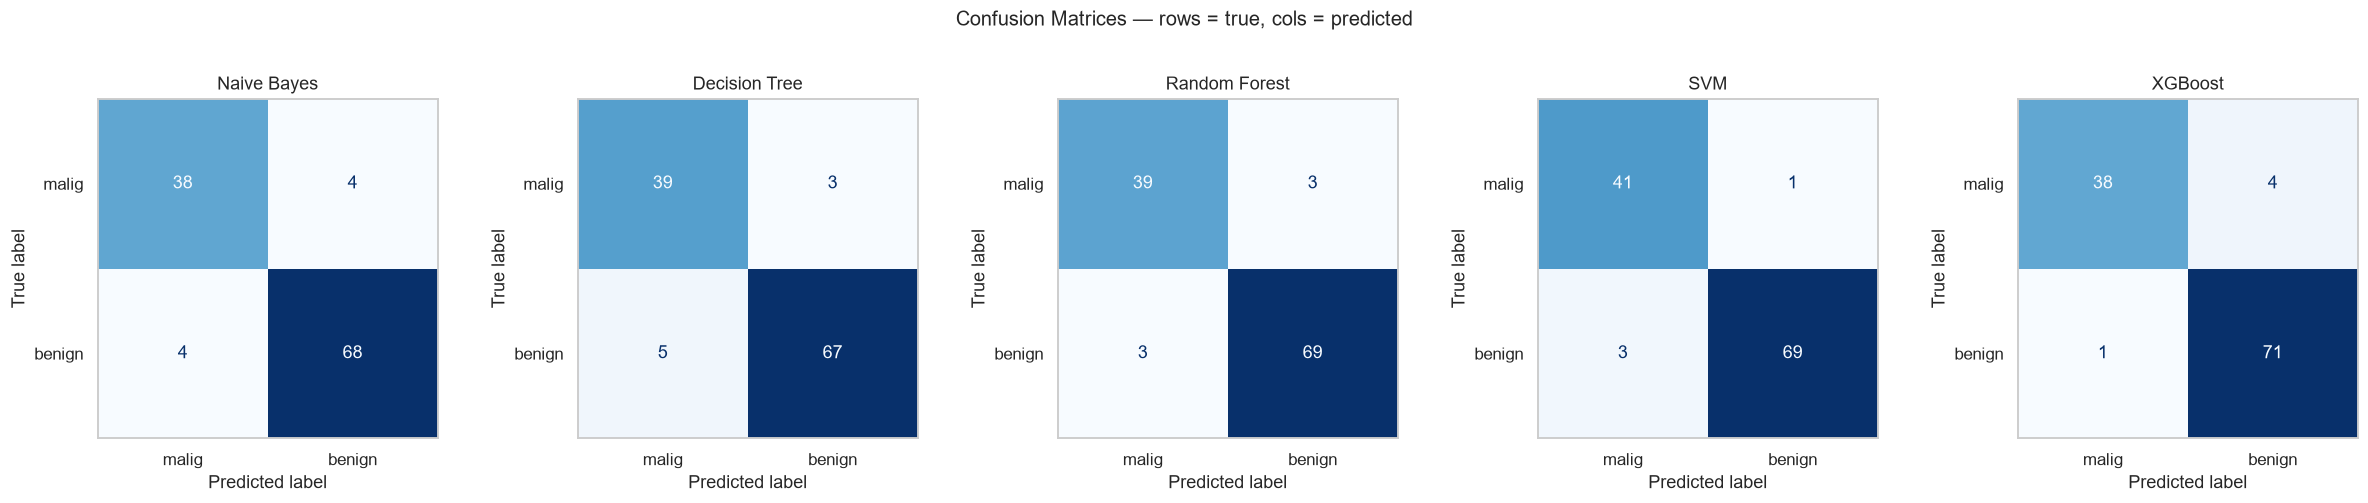

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["malig", "benign"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
    ax.grid(False)
plt.suptitle("Confusion Matrices — rows = true, cols = predicted", y=1.05, fontsize=13)
plt.tight_layout()
plt.savefig("figures/09_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

**How to read these.** The critical cell is *true malignant → predicted benign*
(top-right) — a **false negative**, the dangerous error. Models with the fewest
false negatives (highest malignant recall) are preferred for this problem.

## 7. Save Evaluation Results

In [7]:
metrics_df.to_csv("reports/individual_model_metrics.csv")
print("Saved -> reports/individual_model_metrics.csv")
print("Saved 5 fitted models -> models/*.joblib")
metrics_df

Saved -> reports/individual_model_metrics.csv
Saved 5 fitted models -> models/*.joblib


,Accuracy,Precision,Recall,F1-score
Model,,,,
Naive Bayes,0.9298,0.9048,0.9048,0.9048
Decision Tree,0.9298,0.8864,0.9286,0.9070
Random Forest,0.9474,0.9286,0.9286,0.9286
SVM,0.9649,0.9318,0.9762,0.9535
XGBoost,0.9561,0.9744,0.9048,0.9383


## 8. Summary

All five baseline models were trained **separately** and evaluated on the same
held-out test set with **Accuracy, Precision, Recall, F1** (malignant = positive)
and **confusion matrices**.

- Metrics saved to `reports/individual_model_metrics.csv`.
- Fitted models saved to `models/*.joblib`.
- The next stage (`04_model_comparison.ipynb`) compares these results with
  charts and selects the best-performing model.